# Outlier Suppression 与 OS+：抑制离群值，而不是绕开它

**配套博客**：《Outlier Suppression 与 OS+：当所有人都在保护离群值时，它选择抑制离群值》——LLM PTQ 系列第 10 篇（`github/congyuan_blogs/technology/quantization/ptq/10_outlier_suppression.md`）。

**一段话原理**：LLM 激活里的离群值主要在 LayerNorm 乘 γ 之后成型——训练把少数通道的幅值优势写进尺度参数 γ，使其成为名副其实的「离群值放大器」。OS（Outlier Suppression）据此把 γ 迁移进后继权重（Gamma Migration），拆掉放大器；OS+ 进一步观察到离群通道的分布往往整体偏移（大的正直流分量＋小波动），SmoothQuant 式的逐通道缩放救不了它们自己的分辨率，于是加入通道级平移（shift）。所有变换都能等效迁移回 LN 的 β 与线性层权重/偏置：浮点输出分毫不变，只有量化器看到的分布变乖。本 demo 用 toy 规模合成数据分步复现这条主线：γ 放大与迁移 → 不对称激活上的 shift+scale 对照 → 通道级 clip 边界搜索诊断 → W8A8 误差汇总。全程只用 numpy＋matplotlib，固定 SEED=0，可一键跑完。

## 第 1 步｜公共构件

**这步在做什么**：定义全文共用的对称 per-tensor int8 量化器（W8A8 里激活量化的最坏基线）与层输出相对误差函数，并固定随机种子保证可复现。

In [1]:
import numpy as np
import matplotlib.pyplot as plt

SEED = 0                       # 全文固定随机种子，结果可复现
rng = np.random.default_rng(SEED)

def per_tensor_sym_quant(A, bits=8):
    """对称 per-tensor 量化：整个张量共享一个 absmax 步长"""
    qmax = 2 ** (bits - 1) - 1
    s = np.abs(A).max() / qmax
    return np.round(A / s).clip(-qmax, qmax) * s

def rel_err(Y, Y_ref):
    """层输出的相对 Frobenius 误差"""
    return float(np.linalg.norm(Y - Y_ref) / np.linalg.norm(Y_ref))

print("环境就绪：numpy", np.__version__)

环境就绪：numpy 2.1.1


## 第 2 步｜构造 LN→Linear 合成片段

**这步在做什么**：造一个最小的「LayerNorm → 线性层」片段——归一化后的隐状态 `xhat` 在少数通道本就有 6 倍幅值的常驻苗头（真实 LLM 中存在），训练后的 γ 再在这些通道上放大 5 倍，复现「γ 是离群值放大器」的现场。

In [2]:
D, T, N_OUTLIER = 512, 512, 3          # 通道数 / token 数 / 常驻离群通道数

xhat = rng.normal(0, 1.0, (T, D))      # 归一化后、未加仿射的中间量
out_ch = rng.choice(D, N_OUTLIER, replace=False)
xhat[:, out_ch] *= 6                   # 少数通道的常驻离群苗头

gamma = np.ones(D)
gamma[out_ch] *= 5                     # 训练后的 LN 尺度参数：离群值放大器
beta = rng.normal(0, 0.1, D)           # LN 偏移参数（后面 shift 的迁移宿主）
Wa = rng.normal(0, 0.02, (D, D))       # 下游线性层权重（浮点参照）

a_ln = gamma * xhat + beta             # LN 输出 = 下游线性层的真实输入
print(f"xhat    per-tensor absmax = {np.abs(xhat).max():7.2f}")
print(f"LN 输出 per-tensor absmax = {np.abs(a_ln).max():7.2f}"
      f"   （γ 把动态范围放大 {np.abs(a_ln).max() / np.abs(xhat).max():.1f}x）")
print("γ 被放大的通道:", sorted(out_ch.tolist()))

xhat    per-tensor absmax =   21.40
LN 输出 per-tensor absmax =  106.88   （γ 把动态范围放大 5.0x）
γ 被放大的通道: [87, 456, 487]


## 第 3 步｜Gamma Migration：把 γ 搬进权重

**这步在做什么**：对比两条 W8A8 路径的层输出误差——直接量化 LN 输出，或先做等效变换 $W' = W\,\mathrm{diag}(\gamma)$、$b' = b + W\beta$ 再量化温良的 $\hat{x}$。变换在数学上严格成立：浮点模型的输出分毫不变，变的只是量化器看到的对象。

直接量化 LN 输出   : W8A8 输出相对误差 = 0.0970
Gamma Migration 后 : W8A8 输出相对误差 = 0.0207   （降低 78.7%）


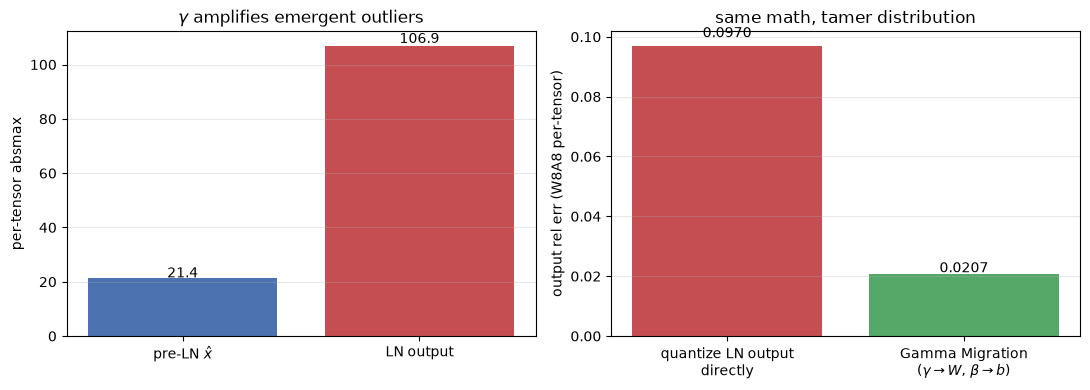

In [3]:
Y_ref = a_ln @ Wa.T                    # 浮点参照输出

# 路径一：直接量化 LN 输出——放大器原样留给量化器
e_direct = rel_err(per_tensor_sym_quant(a_ln) @ Wa.T, Y_ref)

# 路径二：Gamma Migration——γ 折进权重对应列，β 折进 bias
Wa_mig = Wa * gamma[None, :]
b_mig = beta @ Wa.T                    # 常数补偿项走 fp 计算，不参与激活量化
e_mig = rel_err(per_tensor_sym_quant(xhat) @ Wa_mig.T + b_mig, Y_ref)

print(f"直接量化 LN 输出   : W8A8 输出相对误差 = {e_direct:.4f}")
print(f"Gamma Migration 后 : W8A8 输出相对误差 = {e_mig:.4f}"
      f"   （降低 {(1 - e_mig / e_direct) * 100:.1f}%）")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
vals = [np.abs(xhat).max(), np.abs(a_ln).max()]
bars = ax[0].bar(["pre-LN $\hat{x}$", "LN output"], vals,
                 color=["#4C72B0", "#C44E52"])
for b, v in zip(bars, vals):
    ax[0].text(b.get_x() + b.get_width() / 2, v * 1.01, f"{v:.1f}", ha="center")
ax[0].set_ylabel("per-tensor absmax")
ax[0].set_title("$\\gamma$ amplifies emergent outliers")
ax[0].grid(alpha=0.3, axis="y")
bars = ax[1].bar(["quantize LN output\ndirectly",
                  "Gamma Migration\n($\\gamma \\to W$, $\\beta \\to b$)"],
                 [e_direct, e_mig], color=["#C44E52", "#55A868"])
for b, v in zip(bars, [e_direct, e_mig]):
    ax[1].text(b.get_x() + b.get_width() / 2, v * 1.03, f"{v:.4f}", ha="center")
ax[1].set_ylabel("output rel err (W8A8 per-tensor)")
ax[1].set_title("same math, tamer distribution")
ax[1].grid(alpha=0.3, axis="y")
fig.tight_layout()
plt.show()

## 第 4 步｜不对称离群激活

**这步在做什么**：构造 OS+ 论文观察到的「通道间不对称」形态——16/512 个离群通道的取值是大正均值（直流 20～50）加小波动，并把正常通道与离群通道在量化器眼中的分布画出来对照。

原始激活 per-tensor absmax = 48.94
离群通道 472: 直流均值 ≈ 46.3，波动 σ ≈ 0.81


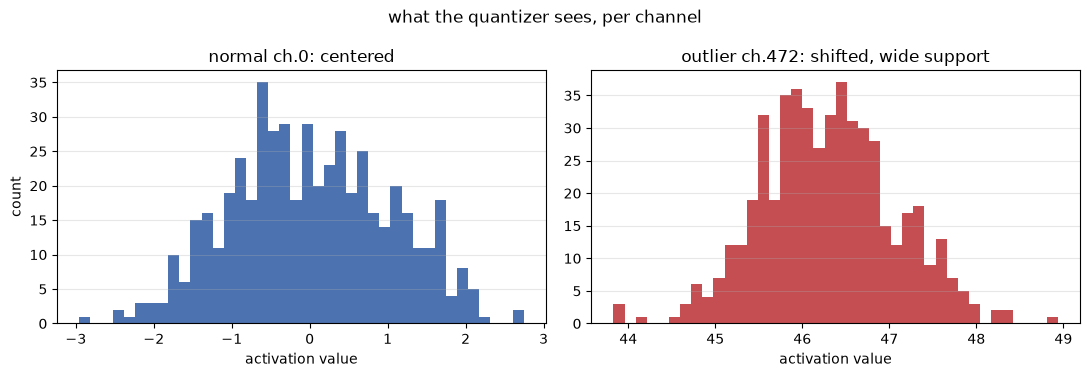

In [4]:
N_OUT2 = 16                            # 不对称离群通道的数量
X = rng.normal(0, 1.0, (T, D))         # 多数通道：零均值高斯
oc = rng.choice(D, N_OUT2, replace=False)
mus = rng.uniform(20.0, 50.0, N_OUT2)  # 每个离群通道自己的正偏移（直流分量）
sigmas = rng.uniform(0.4, 1.0, N_OUT2) # 波动反而很小
for k, j in enumerate(oc):
    X[:, j] = mus[k] + sigmas[k] * rng.normal(0, 1.0, T)
Wb = rng.normal(0, 0.02, (256, D))     # 消费该激活的线性层
Y_ref_b = X @ Wb.T

j_star = oc[np.argmax(mus)]            # 偏移最大的离群通道，后文反复用它讲故事
k_star = list(oc).index(j_star)
normal_ch = int(np.setdiff1d(np.arange(D), oc)[0])
print(f"原始激活 per-tensor absmax = {np.abs(X).max():.2f}")
print(f"离群通道 {j_star}: 直流均值 ≈ {mus[k_star]:.1f}，波动 σ ≈ {sigmas[k_star]:.2f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].hist(X[:, normal_ch], bins=40, color="#4C72B0")
ax[0].set_title(f"normal ch.{normal_ch}: centered")
ax[1].hist(X[:, j_star], bins=40, color="#C44E52")
ax[1].set_title(f"outlier ch.{j_star}: shifted, wide support")
for a in ax:
    a.set_xlabel("activation value")
    a.grid(alpha=0.3, axis="y")
ax[0].set_ylabel("count")
fig.suptitle("what the quantizer sees, per channel")
fig.tight_layout()
plt.show()

## 第 5 步｜shift+scale vs 仅 scale vs 直接量化

**这步在做什么**：在同一 W8A8 per-tensor 预算下跑三种处理，并用「离群通道波动项拿到的有效 int8 级数」（σ ÷ 该通道在原始单位下的网格步长）揭示那个算术事实——逐通道 scale 只是给每个通道发自己的网格，减不掉直流分量就救不了它自己。

shift 使 per-tensor absmax 48.94 -> 4.64（范围收缩 10.5x）
  直接量化              : W8A8 输出相对误差 = 0.0192
  仅 scale（Smooth 型）  : W8A8 输出相对误差 = 0.0028
  shift+scale（OS+）     : W8A8 输出相对误差 = 0.0013

离群通道 472 波动项的有效 int8 级数（σ ÷ 原始单位步长）:
  直接量化     :   2.1 级   （原始单位步长 0.3853）
  仅 scale      :   2.1 级   （原始单位步长 0.3853）
  shift+scale  :  39.0 级   （原始单位步长 0.0208）


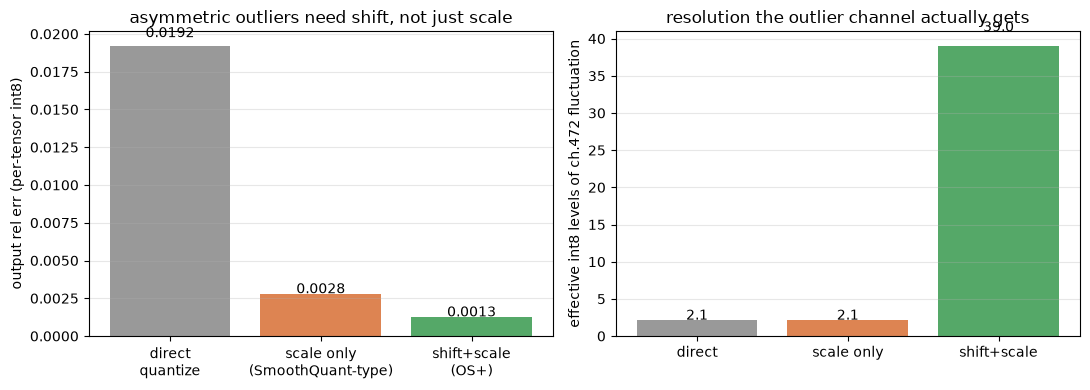

In [5]:
mu = X.mean(0)                         # 校准集逐通道均值 → OS+ 的 shift 向量 δ
s_smooth = np.abs(X).max(0)            # SmoothQuant 口径：不去均值的逐通道 absmax
s_os = np.abs(X - mu).max(0)           # OS+ 口径：先去均值再取逐通道 absmax
Z_os = (X - mu) / s_os                 # OS+ 变换后的激活（量化器看到的样子）
const = mu @ Wb.T                      # shift 的常数补偿（迁入 LN β / bias 的部分）

Y_v1 = per_tensor_sym_quant(X) @ Wb.T                                  # 直接量化
Y_v2 = per_tensor_sym_quant(X / s_smooth) @ (Wb * s_smooth[None, :]).T  # 仅 scale
Y_v3 = per_tensor_sym_quant(Z_os) @ (Wb * s_os[None, :]).T + const      # shift+scale
errs_b = {"direct": rel_err(Y_v1, Y_ref_b),
          "scale_only": rel_err(Y_v2, Y_ref_b),
          "shift_scale": rel_err(Y_v3, Y_ref_b)}

print(f"shift 使 per-tensor absmax {np.abs(X).max():.2f} -> {np.abs(X - mu).max():.2f}"
      f"（范围收缩 {np.abs(X).max() / np.abs(X - mu).max():.1f}x）")
for name, e in zip(["直接量化              ", "仅 scale（Smooth 型）  ",
                    "shift+scale（OS+）     "], errs_b.values()):
    print(f"  {name}: W8A8 输出相对误差 = {e:.4f}")

steps = {"direct": np.abs(X).max() / 127,       # 全局 absmax 决定步长
         "scale_only": s_smooth[j_star] / 127,  # 该通道自己的 absmax 决定其步长
         "shift_scale": s_os[j_star] / 127}     # 去均值后步长大幅缩小
levels = {key: sigmas[k_star] / v for key, v in steps.items()}
print(f"\n离群通道 {j_star} 波动项的有效 int8 级数（σ ÷ 原始单位步长）:")
for name, key in [("直接量化     ", "direct"), ("仅 scale      ", "scale_only"),
                  ("shift+scale  ", "shift_scale")]:
    print(f"  {name}: {levels[key]:5.1f} 级   （原始单位步长 {steps[key]:.4f}）")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
labels = ["direct\nquantize", "scale only\n(SmoothQuant-type)", "shift+scale\n(OS+)"]
vals_e = list(errs_b.values())
bars = ax[0].bar(labels, vals_e, color=["#999999", "#DD8452", "#55A868"])
for b, v in zip(bars, vals_e):
    ax[0].text(b.get_x() + b.get_width() / 2, v * 1.03, f"{v:.4f}", ha="center")
ax[0].set_ylabel("output rel err (per-tensor int8)")
ax[0].set_title("asymmetric outliers need shift, not just scale")
ax[0].grid(alpha=0.3, axis="y")
vals_l = [levels["direct"], levels["scale_only"], levels["shift_scale"]]
bars = ax[1].bar(["direct", "scale only", "shift+scale"], vals_l,
                 color=["#999999", "#DD8452", "#55A868"])
for b, v in zip(bars, vals_l):
    ax[1].text(b.get_x() + b.get_width() / 2, v * 1.05, f"{v:.1f}", ha="center")
ax[1].set_ylabel(f"effective int8 levels of ch.{j_star} fluctuation")
ax[1].set_title("resolution the outlier channel actually gets")
ax[1].grid(alpha=0.3, axis="y")
fig.tight_layout()
plt.show()

## 第 6 步｜实现通道级 clip 边界搜索器

**这步在做什么**：写一个向量化的逐通道网格搜索——对每一列独立地在收缩比例 r∈[0.50, 1.00] 上选使量化 MSE 最小的对称边界 ±r·absmax。这是 OS/AWQ 一族「搜裁剪边界」机制的极简版：边界每收一格，极端样本开始饱和，其余样本却拿到更细的网格，搜索就是替每个通道权衡这笔交易。

In [6]:
CLIP_RATIOS = np.round(np.linspace(0.50, 1.00, 26), 3)   # 边界收缩比例网格

def mse_clip_search(Z, bits=8, ratios=CLIP_RATIOS):
    """通道级 clip 边界搜索：逐列独立选使量化 MSE 最小的收缩比例，
       返回（最优比例，最优边界下的量化结果，最优 MSE）"""
    qmax = 2 ** (bits - 1) - 1
    amax = np.abs(Z).max(axis=0)
    best_mse = np.full(Z.shape[1], np.inf)
    best_ratio = np.ones(Z.shape[1])
    best_q = Z.copy()
    for r in ratios:
        s = r * amax / qmax                     # 该边界下的量化步长
        Q = np.round(Z / s).clip(-qmax, qmax) * s
        mse = ((Q - Z) ** 2).mean(axis=0)
        better = mse < best_mse
        best_mse[better] = mse[better]
        best_ratio[better] = r
        best_q[:, better] = Q[:, better]
    return best_ratio, best_q, best_mse

print(f"搜索网格：r ∈ [{CLIP_RATIOS[0]:.2f}, {CLIP_RATIOS[-1]:.2f}]，共 {len(CLIP_RATIOS)} 个候选边界")

搜索网格：r ∈ [0.50, 1.00]，共 26 个候选边界


## 第 7 步｜运行搜索：原始激活 vs shift 后

**这步在做什么**：把同一套搜索分别跑在没有去均值的原始激活和 shift 后（保留原单位、可与前者同量纲比较）的激活上，检验「先 shift，再谈裁剪」——看搜索在哪种分布上才真的找得到有用的边界。

通道级 clip 边界搜索结果（MSE 准则，原始单位）:
  离群通道 472: 原始激活最优 MSE = 0.012363（r*=1.00）；shift 后 = 0.000037（r*=0.98），相差 332x
  正常通道 0: 原始 = 0.000045，shift 后 = 0.000046——没有偏移可去，shift 既不帮它也不伤它
  shift 后仅 13/512 个通道愿意收缩边界：近高斯分布在 MSE 准则下无尾部可裁——OS+ 的主角是 shift，clip 只是可选收尾


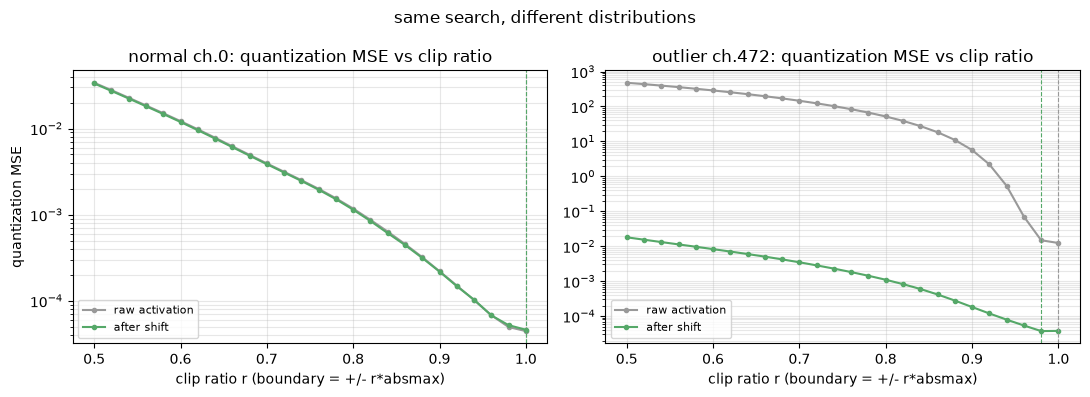

In [7]:
def mse_curve(z, ratios=CLIP_RATIOS, bits=8):
    """单个通道在不同收缩比例下的量化 MSE 曲线（用于画图）"""
    qmax = 2 ** (bits - 1) - 1
    amax = np.abs(z).max()
    out = []
    for r in ratios:
        s = r * amax / qmax
        Q = np.round(z / s).clip(-qmax, qmax) * s
        out.append(((Q - z) ** 2).mean())
    return np.array(out)

ratio_raw, _, mse_raw = mse_clip_search(X)        # 原始激活（含直流偏移）
ratio_sh, _, mse_sh = mse_clip_search(X - mu)     # shift 后（原单位，可直接相比）
n_clipped = int((ratio_sh < 1.0 - 1e-9).sum())

print("通道级 clip 边界搜索结果（MSE 准则，原始单位）:")
print(f"  离群通道 {j_star}: 原始激活最优 MSE = {mse_raw[j_star]:.6f}（r*={ratio_raw[j_star]:.2f}）；"
      f"shift 后 = {mse_sh[j_star]:.6f}（r*={ratio_sh[j_star]:.2f}），"
      f"相差 {mse_raw[j_star] / mse_sh[j_star]:.0f}x")
print(f"  正常通道 {normal_ch}: 原始 = {mse_raw[normal_ch]:.6f}，"
      f"shift 后 = {mse_sh[normal_ch]:.6f}——没有偏移可去，shift 既不帮它也不伤它")
print(f"  shift 后仅 {n_clipped}/{D} 个通道愿意收缩边界：近高斯分布在 MSE 准则下"
      f"无尾部可裁——OS+ 的主角是 shift，clip 只是可选收尾")

fig, ax = plt.subplots(1, 2, figsize=(11, 4), sharex=True)
for a, ch, tag in [(ax[0], normal_ch, "normal"), (ax[1], j_star, "outlier")]:
    a.semilogy(CLIP_RATIOS, mse_curve(X[:, ch]), color="#999999",
               marker=".", label="raw activation")
    a.semilogy(CLIP_RATIOS, mse_curve((X - mu)[:, ch]), color="#55A868",
               marker=".", label="after shift")
    a.axvline(float(ratio_raw[ch]), color="#999999", ls="--", lw=0.8)
    a.axvline(float(ratio_sh[ch]), color="#55A868", ls="--", lw=0.8)
    a.set_title(f"{tag} ch.{ch}: quantization MSE vs clip ratio")
    a.set_xlabel("clip ratio r (boundary = +/- r*absmax)")
    a.grid(alpha=0.3, which="both")
    a.legend(fontsize=8)
ax[0].set_ylabel("quantization MSE")
fig.suptitle("same search, different distributions")
fig.tight_layout()
plt.show()

In [8]:
print("=" * 64)
print("全文汇总（SEED=0，可复现）")
print("=" * 64)
print(f"[Demo A] γ 放大 {np.abs(a_ln).max() / np.abs(xhat).max():.1f}x："
      f"直接量化 {e_direct:.4f} -> Gamma Migration {e_mig:.4f}"
      f"（-{(1 - e_mig / e_direct) * 100:.1f}%）")
print(f"[Demo B] absmax {np.abs(X).max():.2f} -> shift 后 {np.abs(X - mu).max():.2f}；"
      f"W8A8 误差 {errs_b['direct']:.4f} -> {errs_b['scale_only']:.4f}"
      f" -> {errs_b['shift_scale']:.4f}")
print(f"[Clip  ] 同一搜索下，离群通道 {j_star} 的最优边界 MSE 相差 "
      f"{mse_raw[j_star] / mse_sh[j_star]:.0f}x——先 shift，再谈裁剪")

全文汇总（SEED=0，可复现）
[Demo A] γ 放大 5.0x：直接量化 0.0970 -> Gamma Migration 0.0207（-78.7%）
[Demo B] absmax 48.94 -> shift 后 4.64；W8A8 误差 0.0192 -> 0.0028 -> 0.0013
[Clip  ] 同一搜索下，离群通道 472 的最优边界 MSE 相差 332x——先 shift，再谈裁剪


## 结果解读与方法局限

### 结果解读（SEED=0 实测，数字均可复现）

**Demo A｜γ 是放大器，迁移即拆除。** γ 在 3 个通道上取 5 倍后，LN 输出的 per-tensor absmax 从 21.40 被抬到 106.88（5.0x）。同样做 per-tensor int8：直接量化 LN 输出的层输出误差为 **0.0970**，Gamma Migration 后降到 **0.0207**（−78.7%），与博客及 `run.py` 在 4096 token 规模下的 0.1363 → 0.0291（−78.6%）同量级。注意迁移后权重的对应列被放大了同样的倍数，但权重侧走 per-channel 量化，吃得下这种列间悬殊——「不对称性」被搬到了它能被便宜处理的一侧。

**Demo B｜scale 救别人，shift 救自己。** shift 使 per-tensor absmax 从 48.94 收缩到 4.64（10.5x）；三种处理的 W8A8 层输出误差依次为 **0.0192 → 0.0028 → 0.0013**（与 `run.py` 的 0.0179 / 0.0026 / 0.0013 同量级，且 shift+scale 相对仅 scale 把误差再降一半）。最有信息量的是有效级数：离群通道 472（直流 ≈46.3，σ≈0.81）的波动项在三种方案下拿到 **2.1 → 2.1 → 39.0** 级——仅 scale 时该通道的步长由它自己的 absmax 决定，分毫未变（0.3853）；shift 把步长压到 0.0208（约 19 倍）。这正是博客 §4.2 的算术事实：scale 的收益归其余正常通道，shift 才是离群通道自己的救赎。

**第 7 步｜先 shift，再谈裁剪。** 同一套通道级边界搜索：在原始激活上，离群通道的最优边界被整体偏移的支撑集绑架（r*=1.00，最优 MSE 仍高达 0.012363）；shift 后同一通道落到 0.000037，相差 **332 倍**。与此同时，shift 后仅有 13/512 个通道愿意收缩边界（r* 落在 [0.98, 1.00]）——近高斯分布在 MSE 准则下没有尾部可裁。两个事实合起来说明：clip 搜索的价值不在「裁掉多少」，而在它是一台分布健康度诊断仪；这也解释了 OS+ 论文里为什么 shift 是主菜、clip 只是可选收尾。

### 方法局限

1. **静态统计，无法适应漂移**。δ 与 s 由校准集估计后冻结，对长文本、多语言、代码等域外输入的分布漂移没有自适应能力；
2. **等效变换依赖拓扑假设**。shift/scale 的「免费」迁移要求 LN 输出只喂给同分支的线性层，遇到共享 LN、交叉注意力、MoE router 等拓扑要逐一重新论证等价性；
3. **只整形一阶统计**。shift+scale 处理的是位置与幅度，对通道间的相关性（协方差结构）无能为力——这正是旋转路线（QuaRot/SpinQuant）的出发点；
4. **toy 合成与真实的差距**。合成数据的偏移量与离群占比是教学化设定，真实 LLM 各层的 δ 分布更散、校准与推理分布存在天然错位，绝对数字不可外推，结论方向一致。